In [178]:
import pandas as pd
from pathlib import Path

RAW_PATH = Path("../../") / "data" / "laptop_data.csv"
df = pd.read_csv(RAW_PATH, encoding="ISO-8859-1")
df.head()

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"71,378.68"
1,1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"47,895.52"
2,2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"30,636.00"
3,3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"135,195.34"
4,4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"96,095.81"


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1303 entries, 0 to 1302
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        1303 non-null   int64  
 1   Company           1303 non-null   object 
 2   TypeName          1303 non-null   object 
 3   Inches            1303 non-null   float64
 4   ScreenResolution  1303 non-null   object 
 5   Cpu               1303 non-null   object 
 6   Ram               1303 non-null   object 
 7   Memory            1303 non-null   object 
 8   Gpu               1303 non-null   object 
 9   OpSys             1303 non-null   object 
 10  Weight            1303 non-null   object 
 11  Price             1303 non-null   float64
dtypes: float64(2), int64(1), object(9)
memory usage: 122.3+ KB


In [180]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,"1,303.00",NaN,NaN,NaN,651.00,376.29,0.00,325.50,651.00,976.50,"1,302.00"
Company,1303,19,Dell,297,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TypeName,1303,6,Notebook,727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Inches,"1,303.00",NaN,NaN,NaN,15.02,1.43,10.10,14.00,15.60,15.60,18.40
ScreenResolution,1303,40,Full HD 1920x1080,507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cpu,1303,118,Intel Core i5 7200U 2.5GHz,190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Ram,1303,9,8GB,619,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Memory,1303,39,256GB SSD,412,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gpu,1303,110,Intel HD Graphics 620,281,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OpSys,1303,9,Windows 10,1072,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [181]:
df.duplicated().sum()

np.int64(0)

In [182]:
df.isnull().sum()

Unnamed: 0          0
Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [183]:
import requests

def get_exchange_rate():
    response = requests.get('https://api.exchangerate-api.com/v4/latest/INR')
    data = response.json()
    return data['rates']['LKR']

# Get current exchange rate
exchange_rate = get_exchange_rate()
print(f"Current exchange rate: 1 INR = {exchange_rate} LKR")

# Convert the Price column
df['Price'] = df['Price'] * exchange_rate
pd.set_option('display.float_format', '{:,.2f}'.format)

df.head()

Current exchange rate: 1 INR = 3.51 LKR


,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"250,539.18"
1,1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"168,113.29"
2,2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"107,532.36"
3,3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"474,535.63"
4,4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"337,296.29"


In [184]:
df.drop(columns=['Unnamed: 0'], inplace=True)

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,"250,539.18"
1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,"168,113.29"
2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,"107,532.36"
3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,"474,535.63"
4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,"337,296.29"


In [185]:
df['Ram'] = df['Ram'].str.replace('GB', '').astype(int)
df['Weight'] = df['Weight'].str.replace('kg', '').astype(float)

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18"
1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,"168,113.29"
2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,"107,532.36"
3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,"474,535.63"
4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29"


/tmp/ipykernel_621/4162934096.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'] )


<Axes: xlabel='Price', ylabel='Density'>

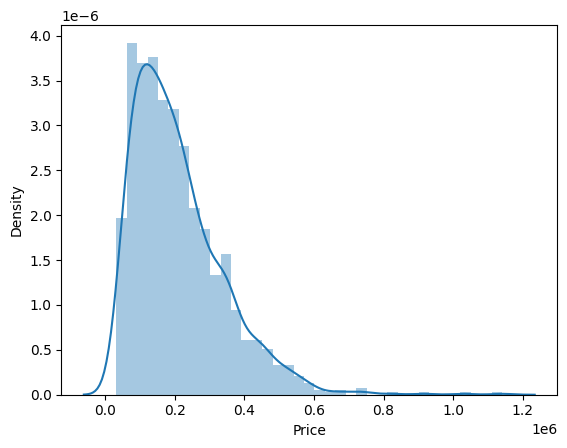

In [186]:
import seaborn as sns

sns.distplot(df['Price'] )

<Axes: title={'center': 'Laptop Companies'}, xlabel='Company'>

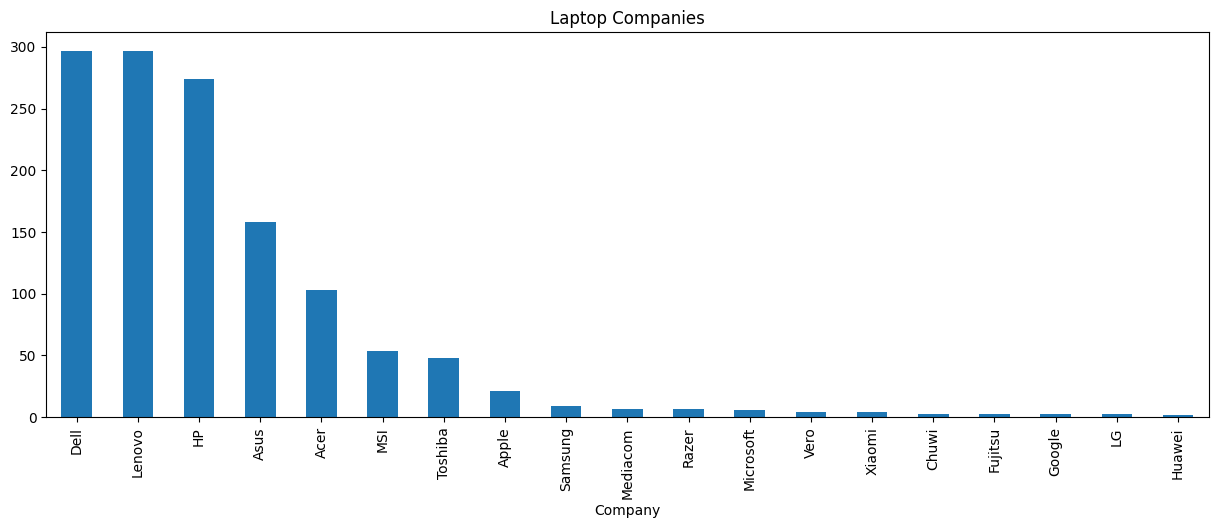

In [187]:
df['Company'].value_counts().plot(kind='bar', figsize=(15, 5), title='Laptop Companies')

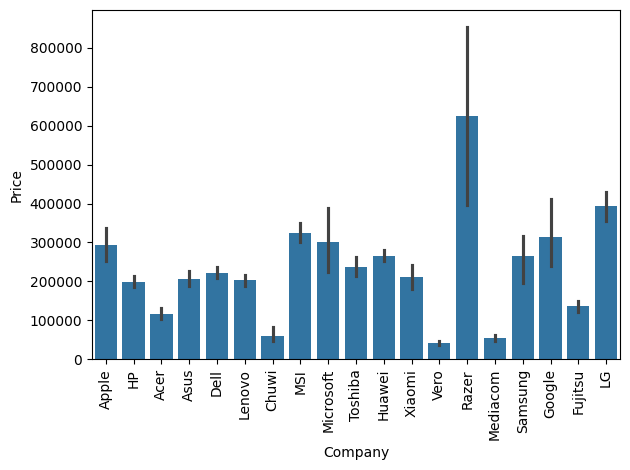

In [188]:
import matplotlib.pyplot as plt      

sns.barplot(x='Company', y='Price', data=df)
plt.xticks(rotation='vertical')      
plt.tight_layout()                     
plt.show()


<Axes: xlabel='TypeName'>

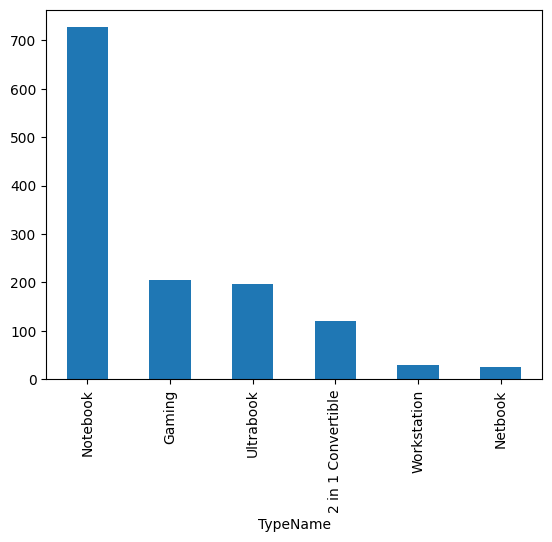

In [189]:
df['TypeName'].value_counts().plot(kind='bar')

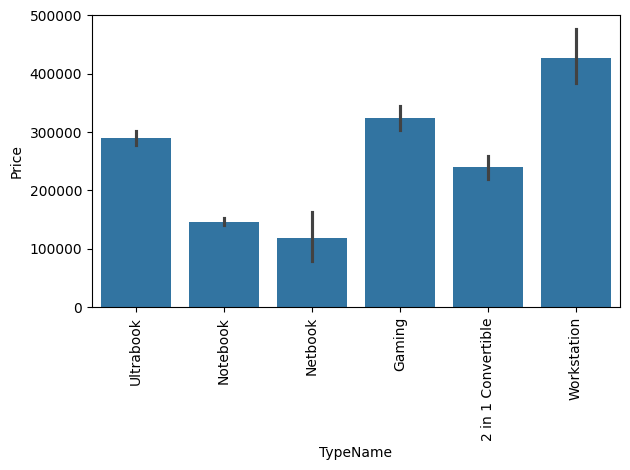

In [190]:
sns.barplot(x='TypeName', y='Price', data=df)
plt.xticks(rotation='vertical')      
plt.tight_layout()                     
plt.show()

/tmp/ipykernel_621/1439577752.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Inches'])


<Axes: xlabel='Inches', ylabel='Density'>

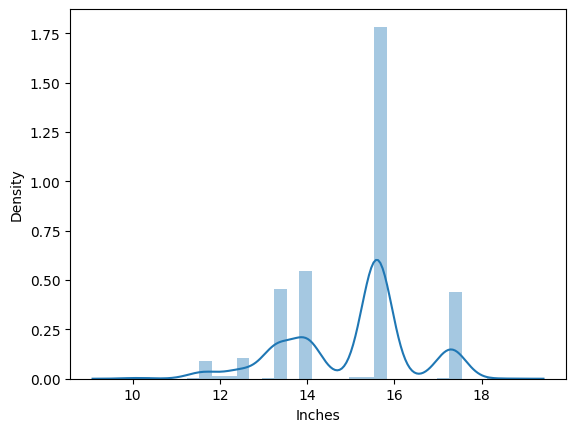

In [191]:
sns.distplot(df['Inches'])

<Axes: xlabel='Inches', ylabel='Price'>

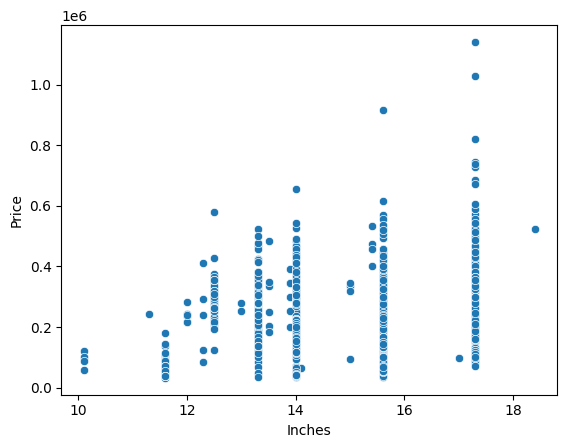

In [192]:
sns.scatterplot(x=df['Inches'], y=df['Price'])

In [193]:
# Extracting Screen Resolution Features
df['Touchscreen'] = df['ScreenResolution'].apply(lambda x:1 if 'Touchscreen' in x else 0)
df['IPS'] = df['ScreenResolution'].apply(lambda x:1 if 'IPS' in x else 0)

temp = df['ScreenResolution'].str.split('x', n=1, expand=True)

df['X_res'] = temp[0]
df['X_res'] = df['X_res'].str.replace(',', '').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0]).astype('int')
df['Y_res'] = temp[1].astype('int')

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res
0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18",0,1,2560,1600
1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,"168,113.29",0,0,1440,900
2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,"107,532.36",0,0,1920,1080
3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,"474,535.63",0,1,2880,1800
4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29",0,1,2560,1600


In [194]:
 
df.corr(numeric_only=True)['Price']

Inches        0.07
Ram           0.74
Weight        0.21
Price         1.00
Touchscreen   0.19
IPS           0.25
X_res         0.56
Y_res         0.55
Name: Price, dtype: float64

In [195]:
# Calculate Pixels Per Inch (PPI) 
df['PPI'] = (df['X_res']**2 + df['Y_res']**2)**0.5/df['Inches'].astype('float')

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,X_res,Y_res,PPI
0,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18",0,1,2560,1600,226.98
1,Apple,Ultrabook,13.30,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,"168,113.29",0,0,1440,900,127.68
2,HP,Notebook,15.60,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,"107,532.36",0,0,1920,1080,141.21
3,Apple,Ultrabook,15.40,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,"474,535.63",0,1,2880,1800,220.53
4,Apple,Ultrabook,13.30,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29",0,1,2560,1600,226.98


In [196]:
df.drop(columns=['ScreenResolution', 'X_res', 'Y_res', 'Inches'], inplace=True)

df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18",0,1,226.98
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,"168,113.29",0,0,127.68
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,"107,532.36",0,0,141.21
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,"474,535.63",0,1,220.53
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29",0,1,226.98


In [197]:
df['Cpu Name'] = df['Cpu'].apply(lambda x:" ".join(x.split()[0:3]))

def fetch_processor(input):
    if input == 'Intel Core i3' or input == 'Intel Core i5' or input == 'Intel Core i7':
        return input
    else:
        if input.split()[0] == 'Intel':
            return 'Other Intel Processor'
        else:
            return 'AMD Processor'

df['Processor'] = df['Cpu Name'].apply(fetch_processor)
df.drop(columns=['Cpu', 'Cpu Name'], inplace=True)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Processor
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18",0,1,226.98,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,"168,113.29",0,0,127.68,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,"107,532.36",0,0,141.21,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,"474,535.63",0,1,220.53,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29",0,1,226.98,Intel Core i5


<Axes: xlabel='Processor'>

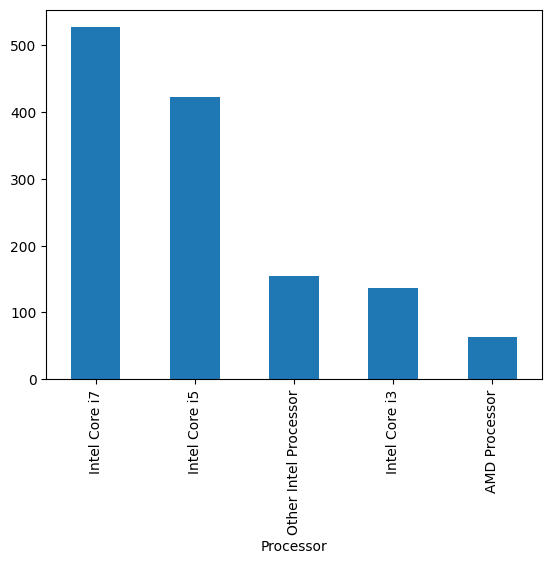

In [198]:
df['Processor'].value_counts().plot(kind='bar')

/tmp/ipykernel_621/3867667222.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Processor', y='Price', data=df, palette='viridis')


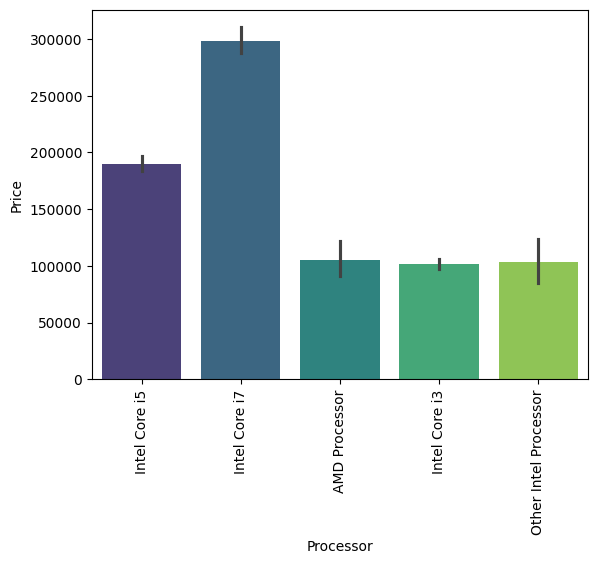

In [199]:
sns.barplot(x='Processor', y='Price', data=df, palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

<Axes: xlabel='Ram'>

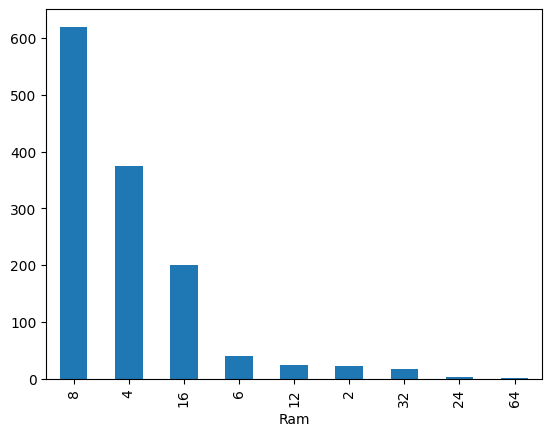

In [200]:
df['Ram'].value_counts().plot(kind='bar')

/tmp/ipykernel_621/3336294569.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ram', y='Price', data=df, palette='viridis')


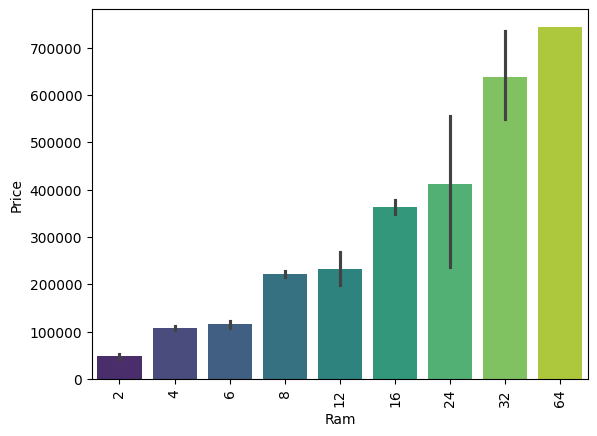

In [201]:
sns.barplot(x='Ram', y='Price', data=df, palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

In [202]:
df['Memory'] = df['Memory'].astype(str)
df['Memory'] = df['Memory'].str.replace(r'(\d+\.?\d*)TB', lambda m: str(int(float(m.group(1)) * 1024)), regex=True)
df['Memory'] = df['Memory'].str.replace('GB', '', regex=False)


new = df['Memory'].str.split('+', n=1, expand=True)
df['Memory'] = new[0].str.strip()
df['Memory2'] = new[1]


df['SSD 1'] = df['Memory'].str.contains('SSD', na=False).astype(int)
df['HDD 1'] = df['Memory'].str.contains('HDD', na=False).astype(int)
df['Flash 1'] = df['Memory'].str.contains('Flash', na=False).astype(int)
df['Hybrid 1'] = df['Memory'].str.contains('Hybrid', na=False).astype(int)


df['Memory'] = df['Memory'].str.replace(r'\D', '', regex=True).replace('', '0').astype(int)


df['Memory2'] = df['Memory2'].fillna('')
df['SSD 2'] = df['Memory2'].str.contains('SSD', na=False).astype(int)
df['HDD 2'] = df['Memory2'].str.contains('HDD', na=False).astype(int)
df['Flash 2'] = df['Memory2'].str.contains('Flash', na=False).astype(int)
df['Hybrid 2'] = df['Memory2'].str.contains('Hybrid', na=False).astype(int)
df['Memory2'] = df['Memory2'].str.replace(r'\D', '', regex=True).replace('', '0').astype(int)

df['HDD']   = df['Memory']  * df['HDD 1']   + df['Memory2'] * df['HDD 2']
df['SSD']   = df['Memory']  * df['SSD 1']   + df['Memory2'] * df['SSD 2']
df['Hybrid'] = df['Memory'] * df['Hybrid 1'] + df['Memory2'] * df['Hybrid 2']
df['Flash_Storage'] = df['Memory'] * df['Flash 1'] + df['Memory2'] * df['Flash 2']

df.drop(columns=[
    'Memory', 'Memory2',
    'HDD 1','SSD 1','Hybrid 1','Flash 1',
    'HDD 2','SSD 2','Hybrid 2','Flash 2'
], inplace=True)

df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Processor,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,"250,539.18",0,1,226.98,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,"168,113.29",0,0,127.68,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,"107,532.36",0,0,141.21,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,"474,535.63",0,1,220.53,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,"337,296.29",0,1,226.98,Intel Core i5,0,256,0,0


In [203]:
df.sample(5)

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,Touchscreen,IPS,PPI,Processor,HDD,SSD,Hybrid,Flash_Storage
772,Toshiba,Notebook,4,Intel HD Graphics 520,Windows 10,1.75,"190,753.06",0,1,111.94,Intel Core i5,0,128,0,0
340,Dell,Notebook,4,Intel HD Graphics,Linux,2.20,"51,409.82",0,0,100.45,Other Intel Processor,500,0,0,0
165,MSI,Gaming,16,Nvidia GeForce GTX 1060,Windows 10,2.40,"336,436.03",0,1,141.21,Intel Core i7,1024,256,0,0
503,Lenovo,Notebook,4,Intel HD Graphics 500,Windows 10,2.10,"55,916.83",0,0,111.94,Other Intel Processor,500,0,0,0
566,Dell,Notebook,4,Intel HD Graphics 620,Windows 10,1.93,"179,345.28",0,0,100.45,Intel Core i5,500,0,0,0


In [204]:
df.corr(numeric_only=True)['Price']

Ram              0.74
Weight           0.21
Price            1.00
Touchscreen      0.19
IPS              0.25
PPI              0.47
HDD             -0.09
SSD              0.67
Hybrid           0.01
Flash_Storage   -0.04
Name: Price, dtype: float64

In [205]:
df['Gpu Name'] = df['Gpu'].apply(lambda x:x.split()[0])

In [206]:
df['Gpu Name'].value_counts()

Gpu Name
Intel     722
Nvidia    400
AMD       180
ARM         1
Name: count, dtype: int64

In [207]:
df = df[df['Gpu Name'] != 'ARM']
df['Gpu Name'].value_counts()

Gpu Name
Intel     722
Nvidia    400
AMD       180
Name: count, dtype: int64

/tmp/ipykernel_621/983066211.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gpu Name', y='Price', data=df, palette='viridis')


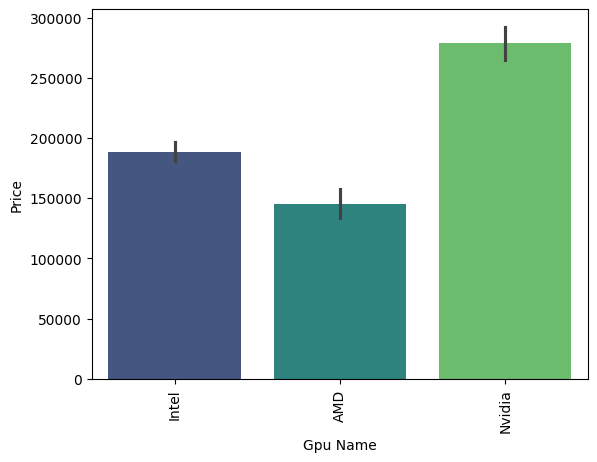

In [208]:
sns.barplot(x='Gpu Name', y='Price', data=df, palette='viridis')
plt.xticks(rotation='vertical')
plt.show()

In [209]:
df.drop(columns=['Gpu'], inplace=True)
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,Touchscreen,IPS,PPI,Processor,HDD,SSD,Hybrid,Flash_Storage,Gpu Name
0,Apple,Ultrabook,8,macOS,1.37,"250,539.18",0,1,226.98,Intel Core i5,0,128,0,0,Intel
1,Apple,Ultrabook,8,macOS,1.34,"168,113.29",0,0,127.68,Intel Core i5,0,0,0,128,Intel
2,HP,Notebook,8,No OS,1.86,"107,532.36",0,0,141.21,Intel Core i5,0,256,0,0,Intel
3,Apple,Ultrabook,16,macOS,1.83,"474,535.63",0,1,220.53,Intel Core i7,0,512,0,0,AMD
4,Apple,Ultrabook,8,macOS,1.37,"337,296.29",0,1,226.98,Intel Core i5,0,256,0,0,Intel


In [210]:
df['OpSys'].value_counts()

OpSys
Windows 10      1072
No OS             66
Linux             62
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

In [211]:
def category_os(input):
    if input == 'Windows 10' or input == 'Windows 7' or input == 'Windows 10 S':
        return 'Windows'
    elif input == 'macOS' or input == 'Mac OS X':
        return 'Mac'
    else:
        return 'Others/No OS/Linux'

df['OS'] = df['OpSys'].apply(category_os)
df.drop(columns=['OpSys'], inplace=True)

df.head()

,Company,TypeName,Ram,Weight,Price,Touchscreen,IPS,PPI,Processor,HDD,SSD,Hybrid,Flash_Storage,Gpu Name,OS
0,Apple,Ultrabook,8,1.37,"250,539.18",0,1,226.98,Intel Core i5,0,128,0,0,Intel,Mac
1,Apple,Ultrabook,8,1.34,"168,113.29",0,0,127.68,Intel Core i5,0,0,0,128,Intel,Mac
2,HP,Notebook,8,1.86,"107,532.36",0,0,141.21,Intel Core i5,0,256,0,0,Intel,Others/No OS/Linux
3,Apple,Ultrabook,16,1.83,"474,535.63",0,1,220.53,Intel Core i7,0,512,0,0,AMD,Mac
4,Apple,Ultrabook,8,1.37,"337,296.29",0,1,226.98,Intel Core i5,0,256,0,0,Intel,Mac


In [212]:
# Saving to current folder
df.to_csv('cleaned_data.csv', index=False)
